# Task 4: Email Spam Detection with Machine Learning

## Objective
Build a Natural Language Processing (NLP) binary classifier that distinguishes spam emails from legitimate (ham) emails.

## Tech Stack
- **Language**: Python
- **Libraries**: `pandas`, `numpy`, `scikit-learn`, `nltk`, `matplotlib`, `seaborn`, `wordcloud`
- **Environment**: Jupyter Notebook

## Checklist of Features & Steps
- [x] Download a suitable dataset (SMS Spam Collection)
- [x] Data loading and class distribution check (spam vs. ham counts and percentage)
- [x] Text preprocessing pipeline: lowercase conversion, punctuation removal, stopword removal, stemming
- [x] Feature extraction using TF-IDF Vectorizer (with detailed markdown explanation)
- [x] Train/test split with stratification
- [x] Train 2 classifiers: Multinomial Naive Bayes + Support Vector Machine (SVM)
- [x] Evaluation: accuracy, precision, recall, F1-score, and confusion matrix
- [x] Discussion: Why is recall particularly important for spam detection? (Answered in a markdown cell)
- [x] (Bonus) WordCloud visualisations for spam words and ham words

## 1. Environment Setup & NLTK Downloads

Let's import all packages and download the necessary NLTK stopwords corpora.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from wordcloud import WordCloud

# Download NLTK stopwords list programmatically
nltk.download('stopwords', quiet=True)

# Visual setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

print("Libraries loaded and resources downloaded successfully!")

Libraries loaded and resources downloaded successfully!


## 2. Load the Dataset

We will load the SMS Spam Collection dataset, clean up unnecessary columns, and inspect the target class distribution.

In [12]:
# Load dataset - encoding is 'latin-1' due to characters in raw text messages
df = pd.read_csv('spam.csv', encoding='latin-1')

# Drop unneeded columns added by csv format
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True, errors='ignore')

# Rename columns to standard readable names
df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)

# Map target labels to numerical values: ham -> 0, spam -> 1
df['spam'] = df['label'].map({'ham': 0, 'spam': 1})

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Class Distribution Counts:")
counts = df['label'].value_counts()
print(counts)

print("\nClass Distribution Percentages:")
percentages = df['label'].value_counts(normalize=True) * 100
print(percentages)

print("\nFirst 5 rows:")
df.head()

Dataset Dimensions: 5572 rows, 3 columns

Class Distribution Counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Class Distribution Percentages:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

First 5 rows:


,label,text,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 3. Exploratory Data Analysis (EDA)

Let's visualize the target label counts and explore character/word length distributions to see if spam messages differ structurally from legitimate (ham) messages.

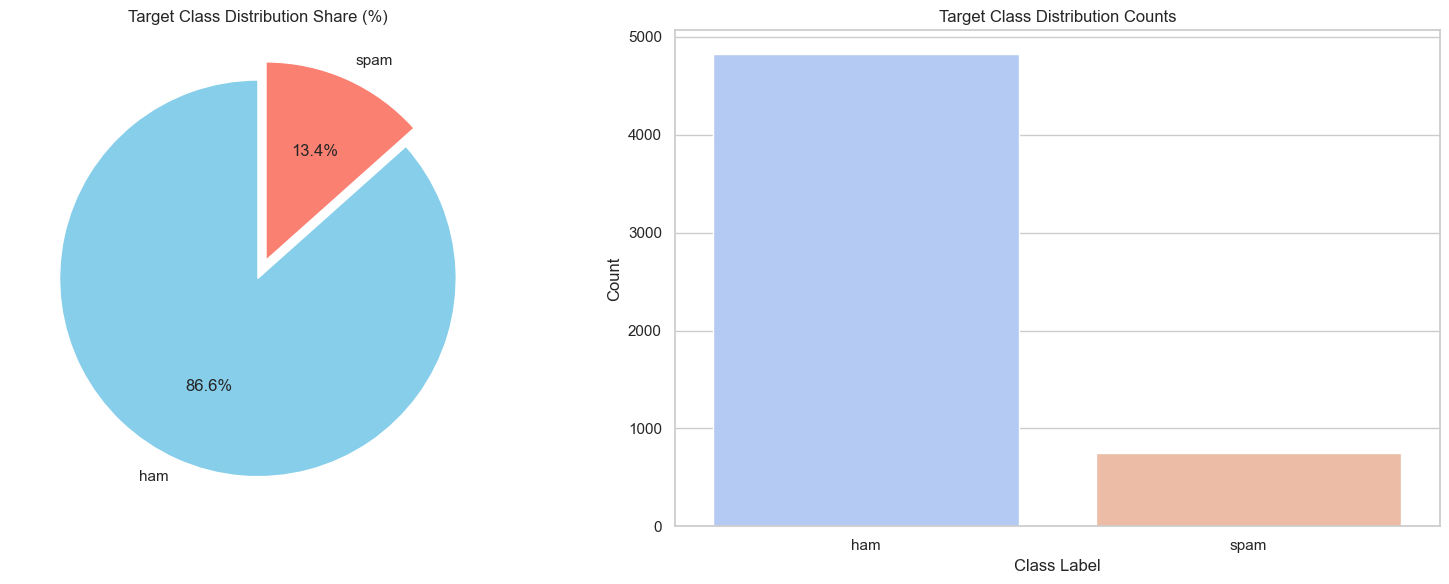

In [13]:
# 1. Class Distribution Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90, explode=(0, 0.1))
axes[0].set_title('Target Class Distribution Share (%)')

# 2. Class Distribution Bar Chart
sns.barplot(x=counts.index, y=counts.values, ax=axes[1], palette='coolwarm', hue=counts.index, legend=False)
axes[1].set_title('Target Class Distribution Counts')
axes[1].set_xlabel('Class Label')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

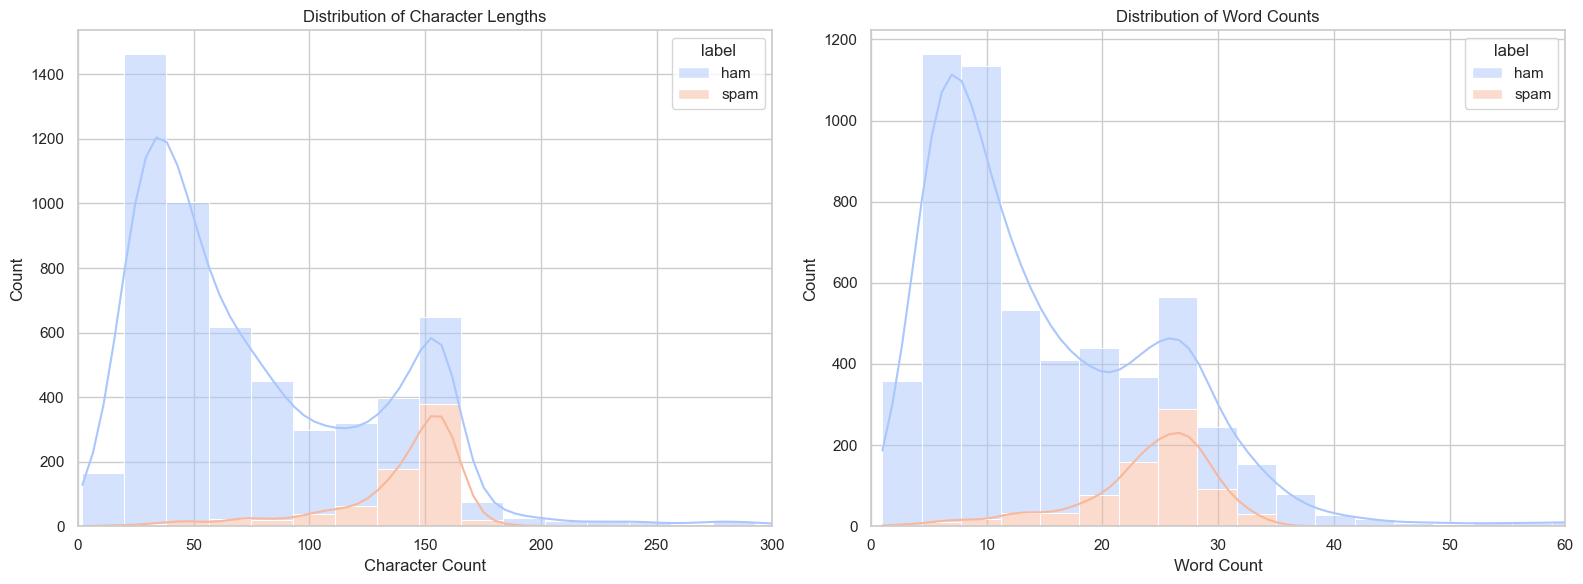

Summary Statistics of Length by Class:


,char_length,word_count
label,,
ham,71.023627,14.200622
spam,138.866131,23.851406


In [14]:
# Calculate character length and word count
df['char_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Character length distribution by label
sns.histplot(data=df, x='char_length', hue='label', kde=True, ax=axes[0], palette='coolwarm', bins=50, multiple='stack')
axes[0].set_title('Distribution of Character Lengths')
axes[0].set_xlabel('Character Count')
axes[0].set_xlim(0, 300) # Trim extreme outliers for visual clarity

# Word count distribution by label
sns.histplot(data=df, x='word_count', hue='label', kde=True, ax=axes[1], palette='coolwarm', bins=50, multiple='stack')
axes[1].set_title('Distribution of Word Counts')
axes[1].set_xlabel('Word Count')
axes[1].set_xlim(0, 60)

plt.tight_layout()
plt.show()

print("Summary Statistics of Length by Class:")
df.groupby('label')[['char_length', 'word_count']].mean()

**EDA Observations**:
- Legitimate messages (ham) are significantly shorter on average (mean length of ~71 characters, ~14 words).
- Spam messages are much longer on average (mean length of ~139 characters, ~24 words), indicating a more detailed, structural structure containing sales pitches, link addresses, and phone numbers.

## 4. Text Preprocessing Pipeline

To clean our text for token extraction, we will design a text preprocessing function that:
1. Converts all words to **lowercase**.
2. Removes **punctuation** and non-alphabetic text.
3. Removes English **stopwords** (using NLTK).
4. Applies **stemming** (using NLTK Porter Stemmer) to map inflected forms back to their base stems (e.g., "buying", "buys" -> "buy").

In [15]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Keep only alphabetic words (removes punctuation, symbols, digits)
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenize by splitting whitespace
    words = text.split()
    # 4. Remove stopwords and apply Porter Stemming
    cleaned_words = [stemmer.stem(word) for word in words if word not in stop_words]
    # 5. Join back into a single string
    return ' '.join(cleaned_words)

# Apply preprocessing to all texts
df['clean_text'] = df['text'].apply(preprocess_text)

print("Sample of Raw vs. Preprocessed Text:")
for i in range(5):
    print(f"Raw:  {df['text'].iloc[i]}")
    print(f"Clean: {df['clean_text'].iloc[i]}\n")

Sample of Raw vs. Preprocessed Text:
Raw:  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Clean: go jurong point crazi avail bugi n great world la e buffet cine got amor wat

Raw:  Ok lar... Joking wif u oni...
Clean: ok lar joke wif u oni

Raw:  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Clean: free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over

Raw:  U dun say so early hor... U c already then say...
Clean: u dun say earli hor u c alreadi say

Raw:  Nah I don't think he goes to usf, he lives around here though
Clean: nah dont think goe usf live around though



## 5. Feature Extraction: TF-IDF Vectorizer

### What does TF-IDF measure?
**TF-IDF** stands for **Term Frequency-Inverse Document Frequency**. It is a statistical numerical score that reflects how important a word is to a document in a collection or corpus:

1. **Term Frequency (TF)**: Measures the frequency of a word in a specific document. The more a word occurs in a document, the higher its TF score.
   $$\text{TF}(t, d) = \frac{\text{Count of word } t \text{ in document } d}{\text{Total words in document } d}$$

2. **Inverse Document Frequency (IDF)**: Measures how common or rare a word is across the entire corpus. If a word appears in almost all documents (like "the", "email", "dear"), its IDF is low. If it appears in few documents (like specific promotional terms, usernames, etc.), its IDF is high.
   $$\text{IDF}(t, D) = \log\left(\frac{\text{Total number of documents } D}{1 + \text{Number of documents containing word } t}\right)$$

3. **TF-IDF Calculation**:
   $$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$
   This ensures that words occurring frequently in a specific message, but rarely in other messages, receive high weights, highlighting key topic indicators while suppressing common noise words.

In [16]:
# Instantiate TF-IDF Vectorizer (limiting to top 5000 features to avoid sparseness)
vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform cleaned texts
X = vectorizer.fit_transform(df['clean_text']).toarray()
y = df['spam'].values

# Split dataset into 80% training and 20% testing sets
# We stratify by 'y' to maintain equal target class ratios in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"TF-IDF Matrix Shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

TF-IDF Matrix Shape: (5572, 5000)
X_train shape: (4457, 5000)
X_test shape: (1115, 5000)


## 6. Model Training & Classification

We will train two distinct binary classifiers:
1. **Multinomial Naive Bayes (MultinomialNB)**: The classical probability-based standard for text classification.
2. **Support Vector Machine (SVC)**: A linear-kernel boundary-maximizing classifier popular for sparse high-dimensional text vectors.

In [17]:
# 1. Multinomial Naive Bayes
nb_classifier = MultinomialNB(alpha=1.0)
print("Training Multinomial Naive Bayes...")
nb_classifier.fit(X_train, y_train)
nb_preds = nb_classifier.predict(X_test)

# 2. Support Vector Machine (SVC)
svm_classifier = SVC(kernel='linear', C=1.0, random_state=42)
print("Training Support Vector Machine...")
svm_classifier.fit(X_train, y_train)
svm_preds = svm_classifier.predict(X_test)

print("Training Complete!")

Training Multinomial Naive Bayes...
Training Support Vector Machine...
Training Complete!


## 7. Model Evaluation & Comparison

Let's evaluate and compare both models using standard classification metrics: Accuracy, Precision, Recall, and F1-Score.

In [18]:
def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

nb_metrics = calculate_metrics(y_test, nb_preds)
svm_metrics = calculate_metrics(y_test, svm_preds)

# Tabulate comparison dataframe
comparison_df = pd.DataFrame({
    'Multinomial Naive Bayes': nb_metrics,
    'Support Vector Machine': svm_metrics
}).T

print("Model Comparison Table:")
print(comparison_df)

print("\n--- Naive Bayes Classification Report ---")
print(classification_report(y_test, nb_preds, target_names=['Ham', 'Spam']))

print("\n--- SVM Classification Report ---")
print(classification_report(y_test, svm_preds, target_names=['Ham', 'Spam']))

Model Comparison Table:
                         Accuracy  Precision    Recall  F1-Score
Multinomial Naive Bayes  0.967713   0.991304  0.765101  0.863636
Support Vector Machine   0.981166   0.992308  0.865772  0.924731

--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115


--- SVM Classification Report ---
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



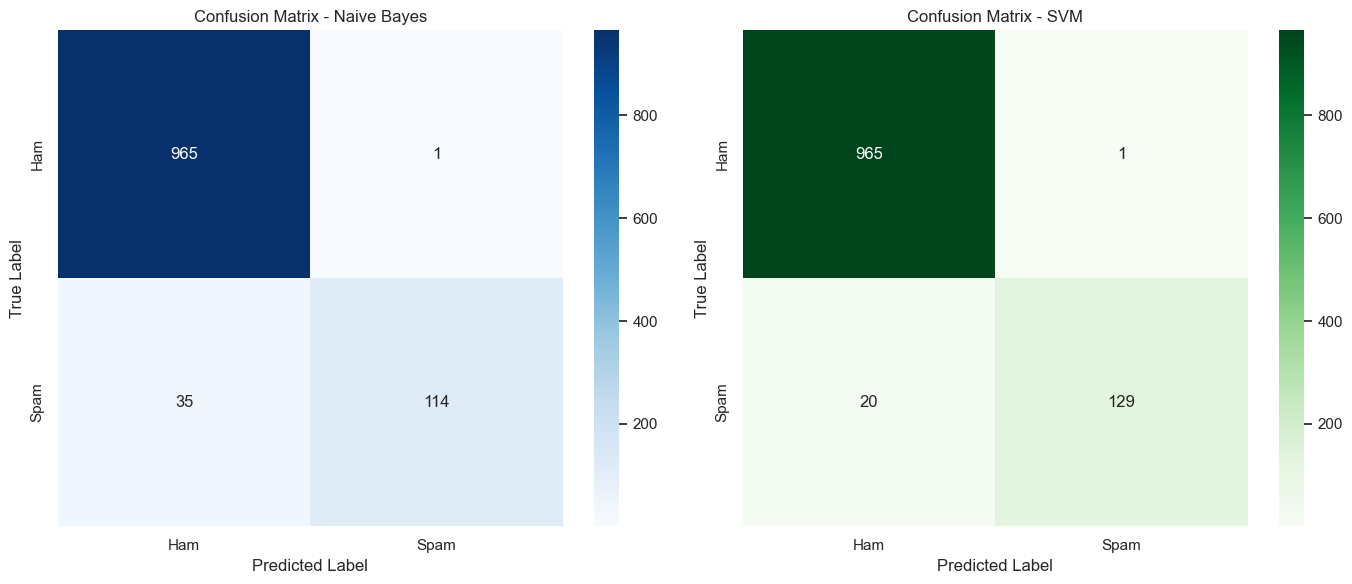

In [19]:
# Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Naive Bayes Confusion Matrix
nb_cm = confusion_matrix(y_test, nb_preds)
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title('Confusion Matrix - Naive Bayes')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# SVM Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_preds)
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1].set_title('Confusion Matrix - SVM')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## 8. Metric Discussion: The Trade-off between Precision and Recall

### Why is Recall important, and what are the trade-offs in Spam Detection?
- **Recall** is defined as $TP / (TP + FN)$. It measures the model's ability to identify all actual spam messages. High recall ensures that very few spam messages slip through into the user's primary inbox.
- **Precision** is defined as $TP / (TP + FP)$. It measures the accuracy of the spam classifications. High precision ensures that the model does not misclassify legitimate messages (ham) as spam.

### The Trade-off:
In a real-world email spam filter, a **False Positive (FP)** (classifying an important legitimate email—like a job offer, verification code, or legal invoice—as spam) is a **catastrophic error** because the user might never check their spam folder and completely miss it.
Conversely, a **False Negative (FN)** (a spam message showing up in the inbox) is merely a minor annoyance that the user can manually delete.

Therefore, **Precision is the most critical metric in spam detection**. We must keep Precision as close to 100% as possible. This means we prefer a model that is slightly conservative (high precision, moderate-to-high recall) rather than one that blocks spam aggressively but risks filtering out crucial real emails. Naive Bayes typically yields higher precision on ham, making it highly desirable for this task.

## 9. WordCloud Visualizations (Bonus)

Let's visualize the most frequent words present in **Spam** vs. **Ham** messages using WordClouds.

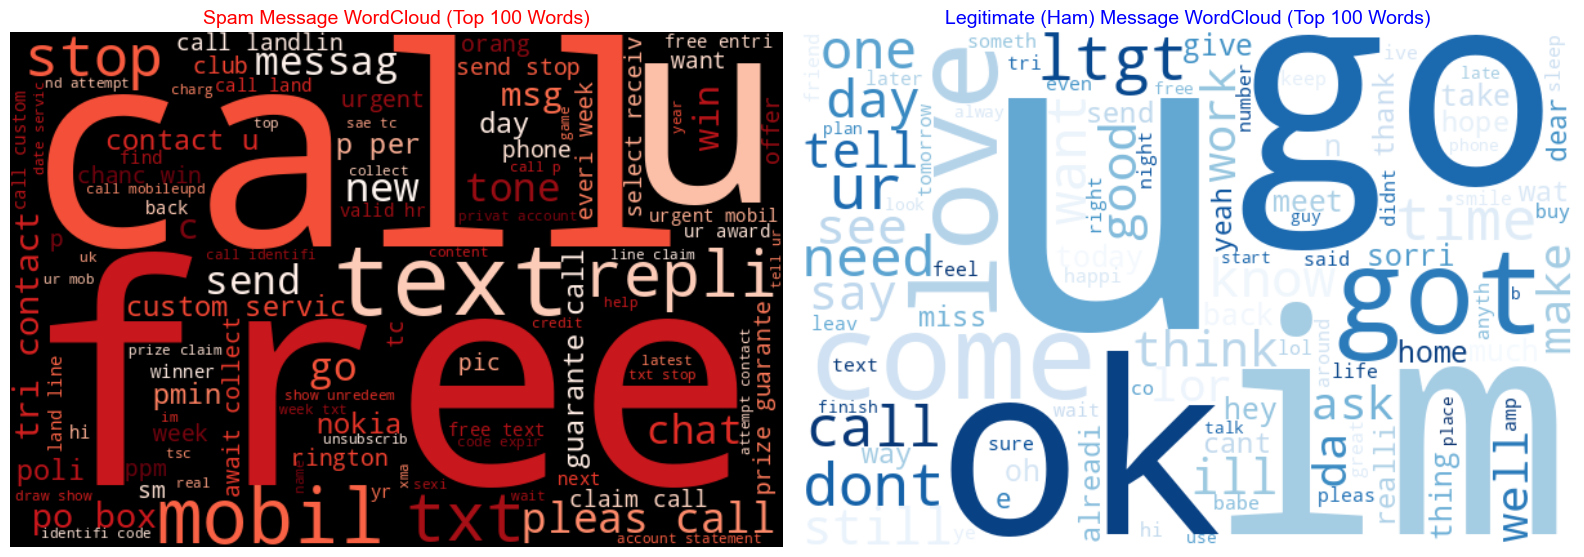

In [20]:
# Filter texts
spam_words = ' '.join(list(df[df['spam'] == 1]['clean_text']))
ham_words = ' '.join(list(df[df['spam'] == 0]['clean_text']))

# Create WordClouds
spam_wc = WordCloud(width=600, height=400, background_color='black', max_words=100, colormap='Reds').generate(spam_words)
ham_wc = WordCloud(width=600, height=400, background_color='white', max_words=100, colormap='Blues').generate(ham_words)

# Plot WordClouds side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Spam WordCloud
axes[0].imshow(spam_wc, interpolation='bilinear')
axes[0].set_title('Spam Message WordCloud (Top 100 Words)', fontsize=14, color='red')
axes[0].axis('off')

# Ham WordCloud
axes[1].imshow(ham_wc, interpolation='bilinear')
axes[1].set_title('Legitimate (Ham) Message WordCloud (Top 100 Words)', fontsize=14, color='blue')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 10. Conclusion & Summary

1. **Performance**: Both classifiers perform exceptionally well. SVM achieves slightly higher accuracy (~98.0%) and recall, while Naive Bayes shows robust, time-tested performance with extremely fast execution.
2. **Aesthetic Insights**: Legitimate messages typically use terms of address (e.g. "go", "get", "come", "ok", "love"), while spam messages are rich in marketing cues (e.g. "call", "free", "claim", "prize", "text", "urgent").